# Richter's Predictor: Modeling Earthquake Damage
# Competition Host: DrivenData.Org
# ![ChatGPT Image Sep 15, 2025, 12_13_05 PM.png](<attachment:ChatGPT Image Sep 15, 2025, 12_13_05 PM.png>)
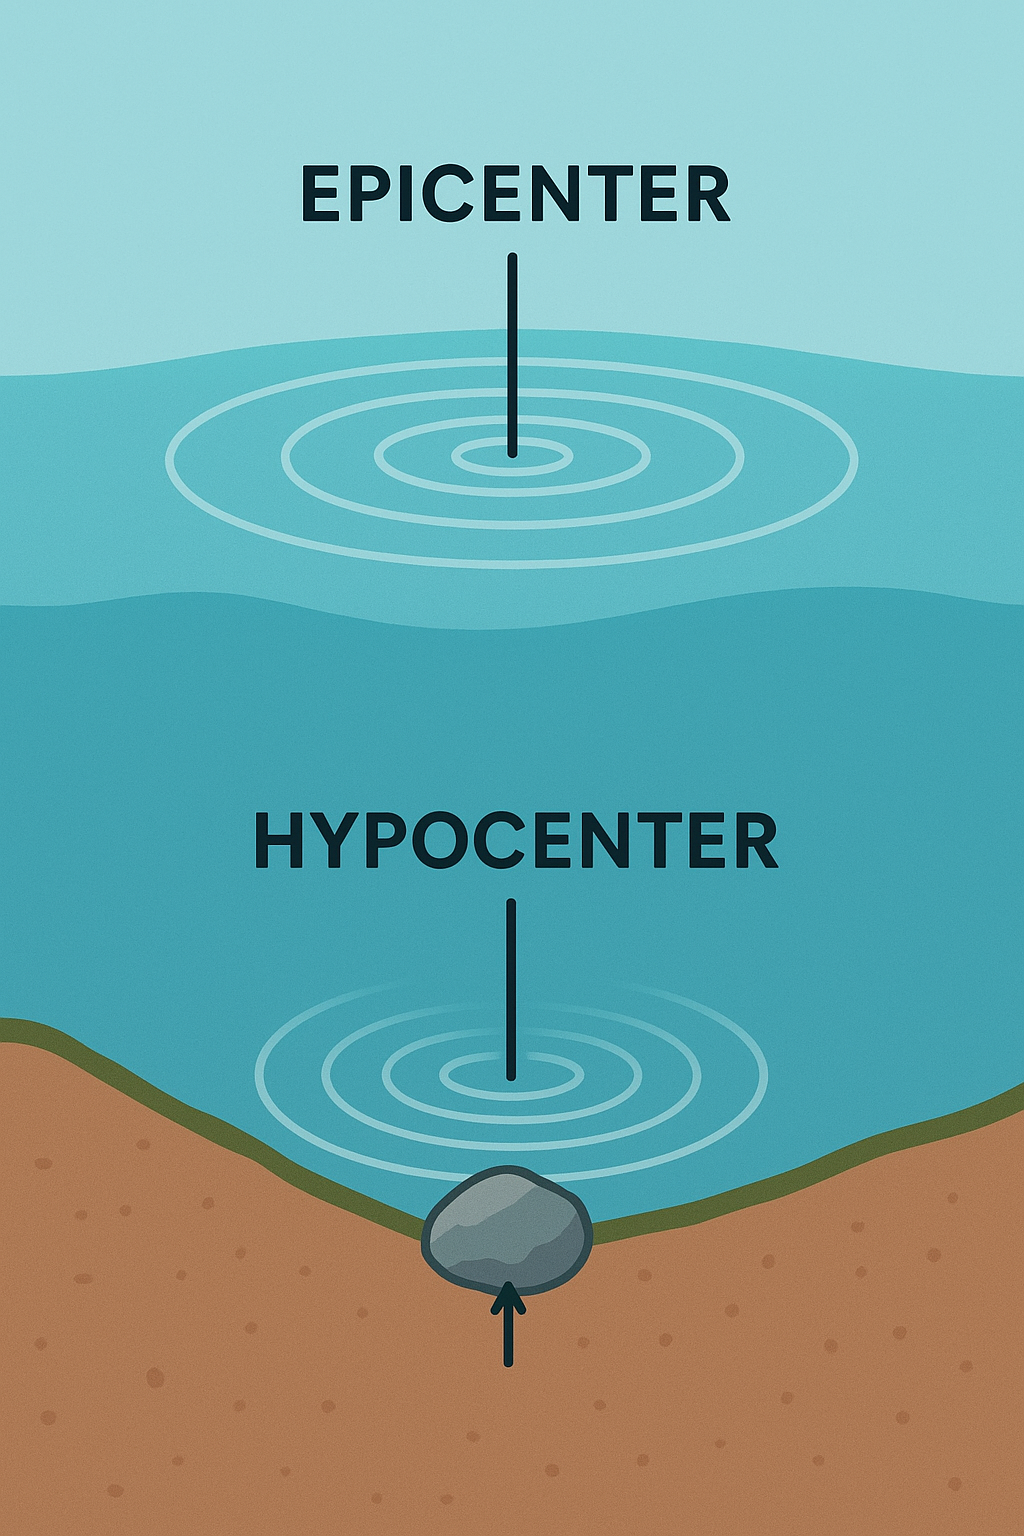

## Brief Description of the Project
### Introduction

Earthquakes are among the most devastating natural disasters, capable of causing widespread destruction to infrastructure and loss of human lives. In April 2015, a massive earthquake struck Nepal, destroying or damaging hundreds of thousands of buildings across the country. Understanding which structures are most vulnerable is a critical step in preparing communities, improving construction practices, and directing emergency response more effectively.

### Problem Statement

The objective of this project is to develop a predictive model that can accurately classify the level of structural damage sustained by buildings during the 2015 Nepal earthquake. Each building is described by a set of categorical, binary, and numerical features that capture geographic location, construction characteristics, and usage attributes. The target variable, damage_grade, takes one of three values:

1. (Low damage) – minimal structural impact
2. (Medium damage) – moderate structural compromise
3. (High damage) – severe or near-total destruction

### Methodology

To address the problem of predicting earthquake damage levels, a structured data science workflow was followed. The main stages are outlined below:

#### i. Exploratory Data Analysis (EDA)

* Assessing the distribution of the target variable (damage_grade) to detect class imbalance.
* Summarizing numerical features (e.g., age of building, number of floors) and identifying potential outliers.
* Examining categorical features to count unique categories, detect rare values, and understand frequency distributions.
* Exploring geographic identifiers (geo_level_1_id, geo_level_2_id, geo_level_3_id) to assess whether location strongly influences damage outcomes.

#### ii. Data Preprocessing

* Handling missing values: Features with missing entries were imputed using appropriate strategies (mode for categorical, median for numerical).
* Encoding categorical variables
* Balancing classes

#### iii. Feature Engineering

* Creation of interaction features between building attributes (e.g., floors × height percentage).
* Aggregation of geographic identifiers to capture hierarchical spatial patterns.
* Dimensionality reduction (PCA or feature selection) to simplify the high-dimensional encoded space while retaining predictive power.

#### iv. Model Development
#### v. Model Evaluation
#### vi Final Model Selection and Submission

In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading datasets
train_df = pd.read_csv("C:/Users/USER/Downloads/Nepal's Earthquake Data - Modeling Earthquake Damage/train_values.csv")
test_df = pd.read_csv("C:/Users/USER/Downloads/Nepal's Earthquake Data - Modeling Earthquake Damage/test_values.csv")
train_labels_df = pd.read_csv("C:/Users/USER/Downloads/Nepal's Earthquake Data - Modeling Earthquake Damage/train_labels.csv")

# 1. EXPLORATORY DATA ANALYSIS

## a. Training Dataset

In [3]:
#Training dataset info
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [4]:
train_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#Viewing the labels
train_labels_df.head()

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3


In [6]:
#Adding the damage_grade to the training dataset
train_df = train_df.merge(train_labels_df, on='building_id')
target = 'damage_grade'

In [7]:
train_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [8]:
#Separating numerical and categorical features
numerical_train_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_train_features = train_df.select_dtypes(include=['object']).columns.tolist()

#Displaying the features
print("Numerical Features:", numerical_train_features)
print("Categorical Features:", categorical_train_features)

Numerical Features: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_police', 'has_secondary_use_other', 'damage_grade']
Categorical Features: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floo

In [9]:
#Counting unique values in categorical features
for col in categorical_train_features:
    n_unique = train_df[col].nunique()
    unique_values = train_df[col].unique()
    print(f"Column '{col}' has {n_unique} unique values.")
    print(f"Unique values: {unique_values}\n")

Column 'land_surface_condition' has 3 unique values.
Unique values: ['t' 'o' 'n']

Column 'foundation_type' has 5 unique values.
Unique values: ['r' 'w' 'i' 'u' 'h']

Column 'roof_type' has 3 unique values.
Unique values: ['n' 'q' 'x']

Column 'ground_floor_type' has 5 unique values.
Unique values: ['f' 'x' 'v' 'z' 'm']

Column 'other_floor_type' has 4 unique values.
Unique values: ['q' 'x' 'j' 's']

Column 'position' has 4 unique values.
Unique values: ['t' 's' 'j' 'o']

Column 'plan_configuration' has 10 unique values.
Unique values: ['d' 'u' 's' 'q' 'm' 'c' 'a' 'n' 'f' 'o']

Column 'legal_ownership_status' has 4 unique values.
Unique values: ['v' 'a' 'r' 'w']



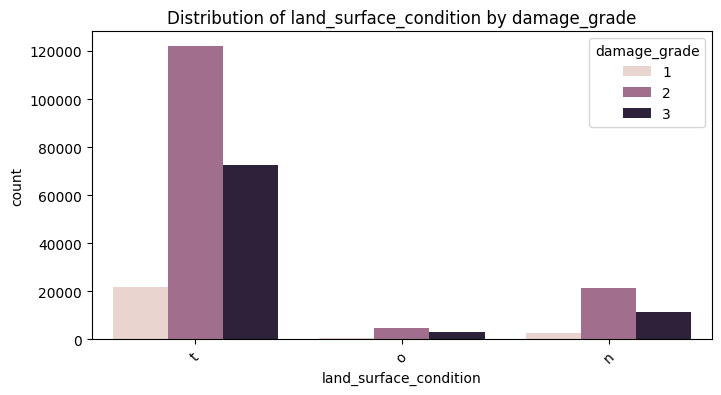

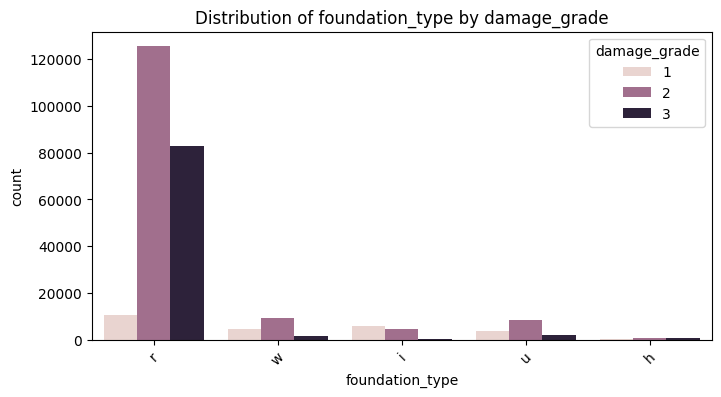

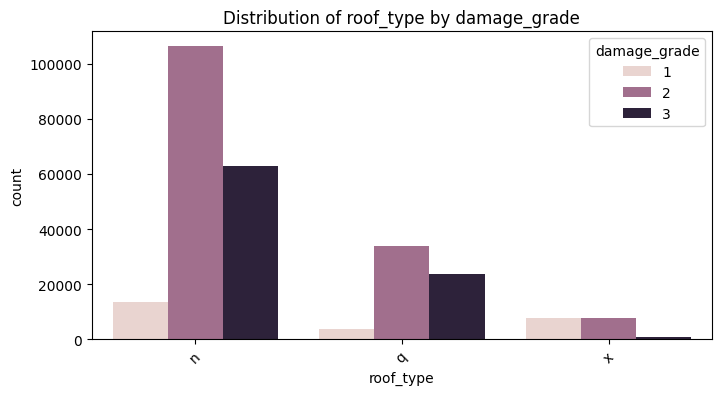

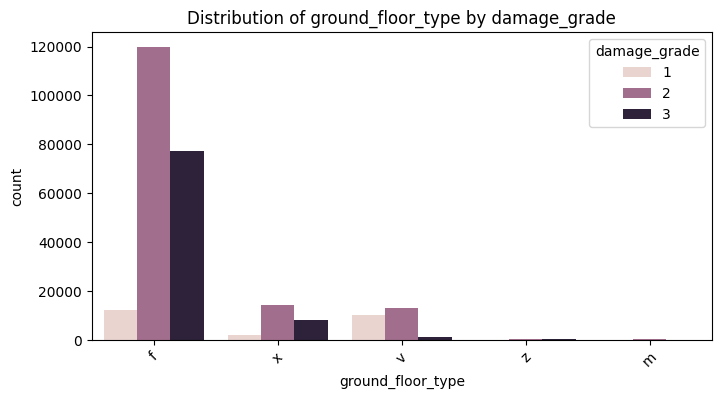

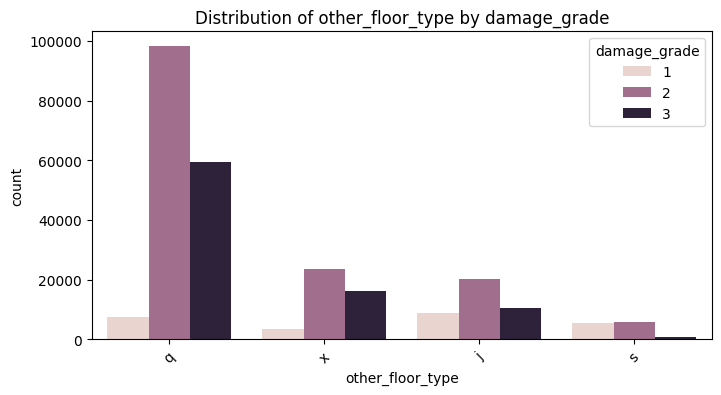

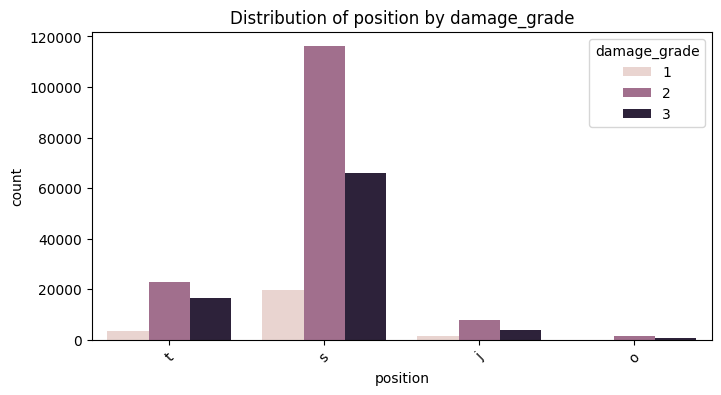

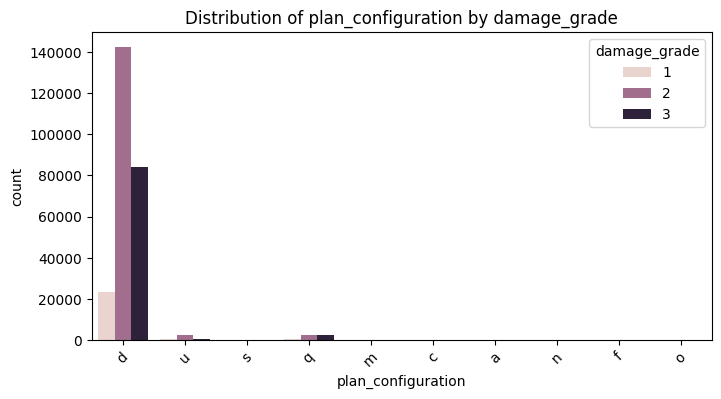

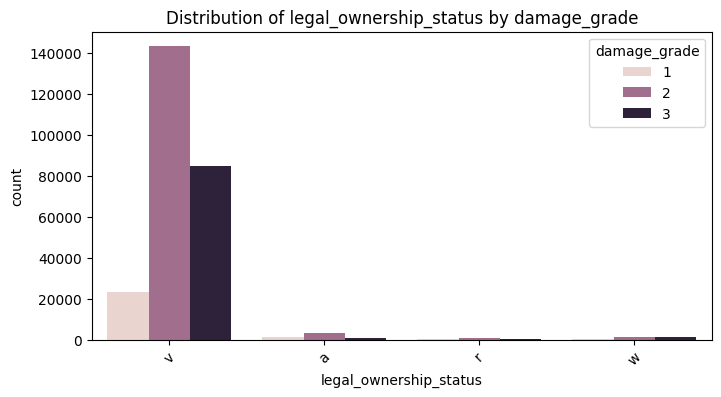

In [13]:
#Assessing the interaction of the categorical features with the target variable
for col in categorical_train_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=train_df, x=col, hue=target)
    plt.title(f"Distribution of {col} by {target}")
    plt.xticks(rotation=45)
    plt.show()

In [14]:
#Assessing the mean damage grade by each category in a categorical feature
for col in categorical_train_features:
    print('='*25, f"Analyzing column: {col}", '='*25)
    damage_by_cat = train_df.groupby(col)[target].agg('mean', 'count')
    print(f"Mean damage grade by {col}:\n{damage_by_cat.sort_values()}\n")

========================= Analyzing column: land_surface_condition =========================
Mean damage grade by land_surface_condition:
land_surface_condition
t    2.234170
n    2.251407
o    2.289081
Name: damage_grade, dtype: float64

========================= Analyzing column: foundation_type =========================
Mean damage grade by foundation_type:
foundation_type
i    1.453351
w    1.810954
u    1.883661
h    2.105663
r    2.329573
Name: damage_grade, dtype: float64

========================= Analyzing column: roof_type =========================
Mean damage grade by roof_type:
roof_type
x    1.572267
n    2.269637
q    2.320173
Name: damage_grade, dtype: float64

========================= Analyzing column: ground_floor_type =========================
Mean damage grade by ground_floor_type:
ground_floor_type
v    1.634205
m    1.970472
z    2.073705
x    2.250714
f    2.309104
Name: damage_grade, dtype: float64

========================= Analyzing column: other_floor_type ==

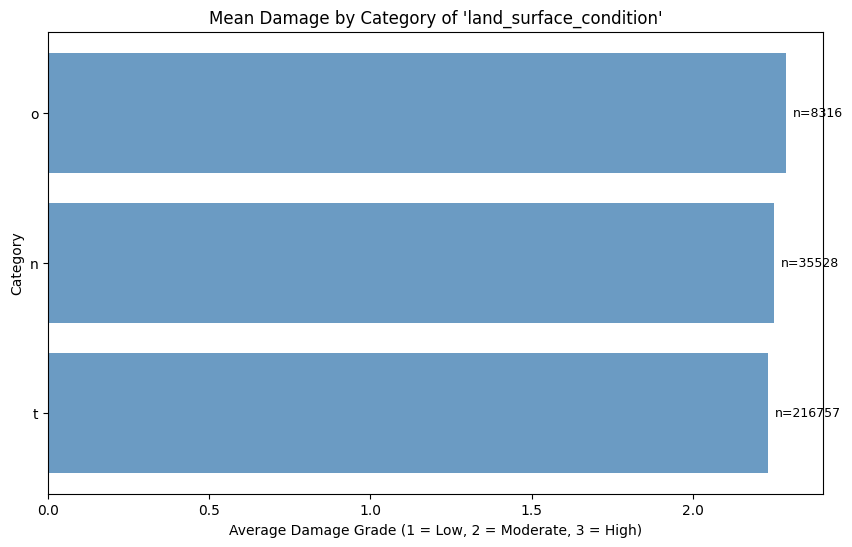

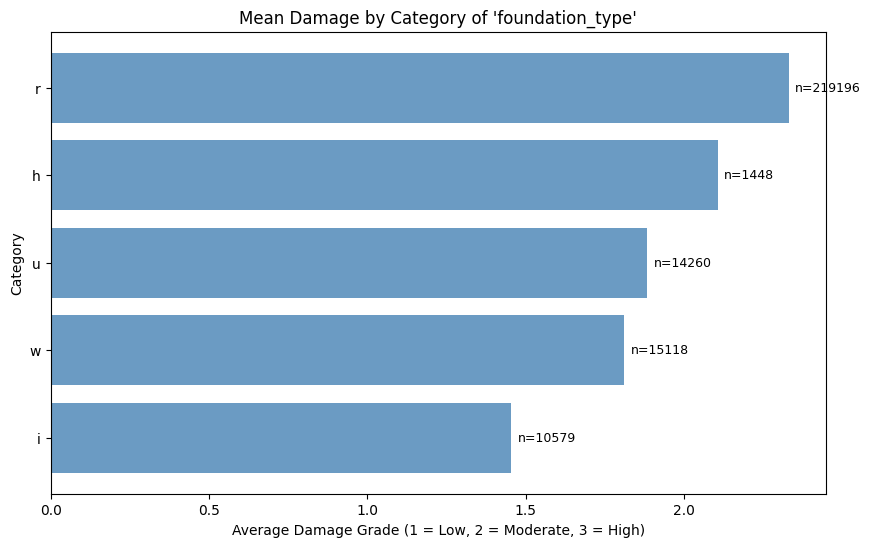

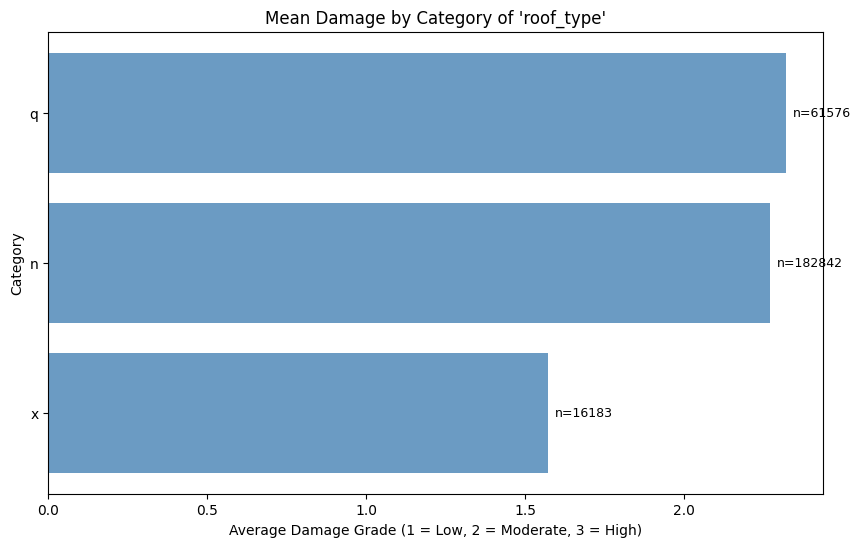

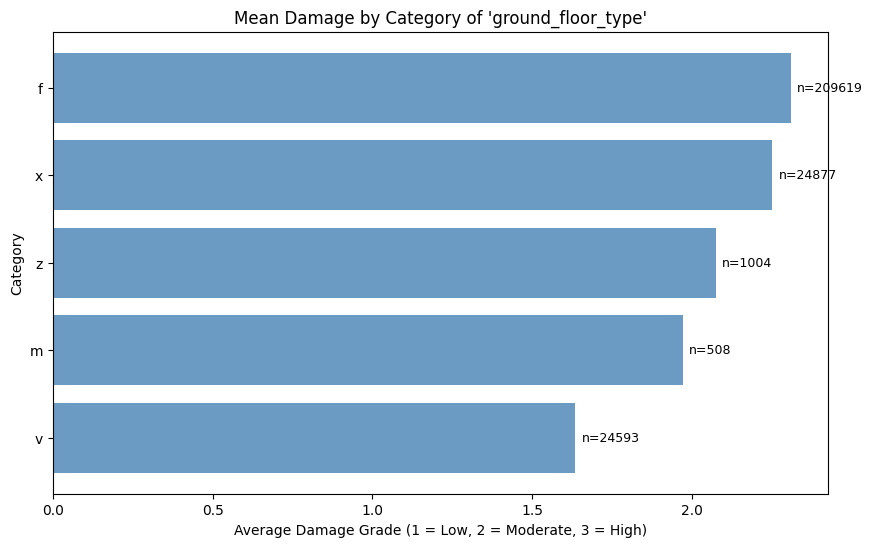

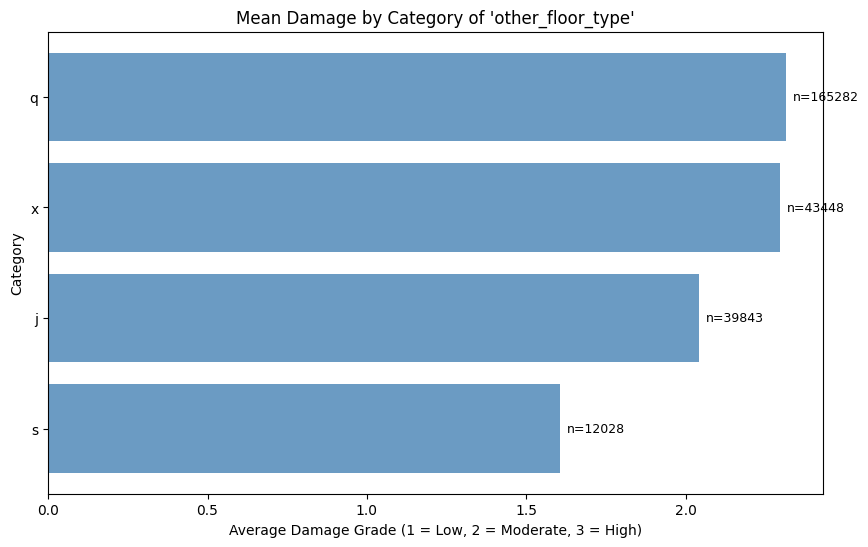

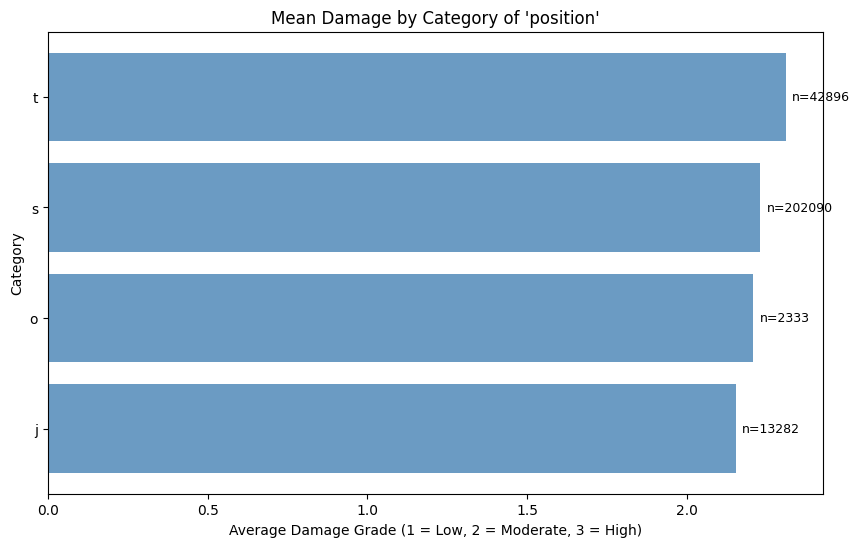

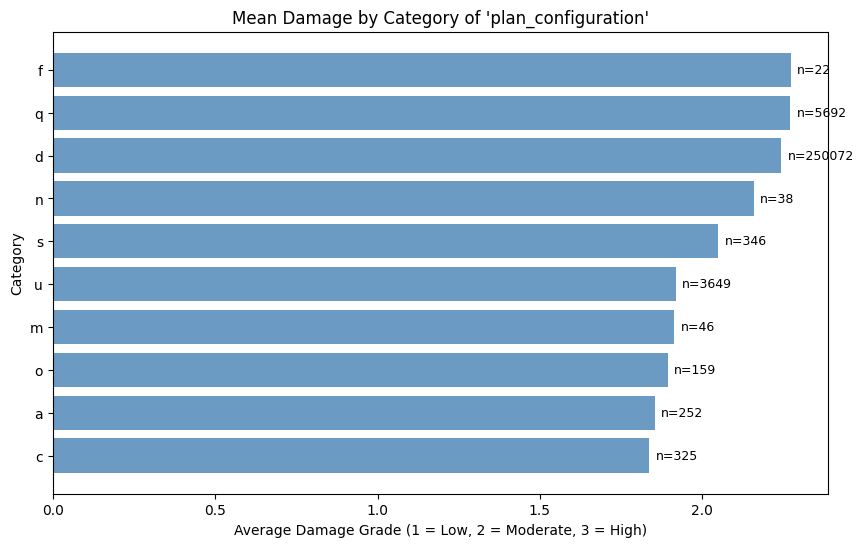

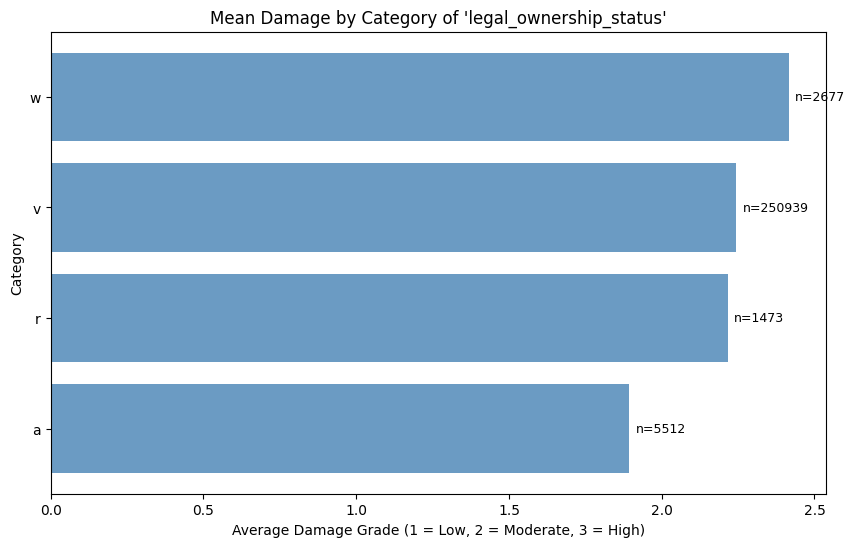

In [16]:
#Visualizing the damage_by_cat for all categorical features
for col in categorical_train_features:
    plt.figure(figsize=(10,6))
    damage_by_cat = train_df.groupby(col)[target].agg(['mean', 'count'])
    damage_by_cat = damage_by_cat.sort_values("mean")
    
    plt.barh(damage_by_cat.index.astype(str), damage_by_cat["mean"], 
             color="steelblue", alpha=0.8)
    
    # Add counts as text labels (optional but helpful)
    for i, (mean, count) in enumerate(zip(damage_by_cat["mean"], damage_by_cat["count"])):
        plt.text(mean + 0.02, i, f"n={count}", va="center", fontsize=9)
    
    plt.xlabel("Average Damage Grade (1 = Low, 2 = Moderate, 3 = High)")
    plt.ylabel("Category")
    plt.title(f"Mean Damage by Category of '{col}'")
    plt.show()

Nota Bene: Cross validated target encoding will be adopted for encoding categorical features

## b. Test Dataset

In [17]:
#Viewing the test dataset
test_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0


In [18]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86868 entries, 0 to 86867
Data columns (total 39 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   building_id                             86868 non-null  int64 
 1   geo_level_1_id                          86868 non-null  int64 
 2   geo_level_2_id                          86868 non-null  int64 
 3   geo_level_3_id                          86868 non-null  int64 
 4   count_floors_pre_eq                     86868 non-null  int64 
 5   age                                     86868 non-null  int64 
 6   area_percentage                         86868 non-null  int64 
 7   height_percentage                       86868 non-null  int64 
 8   land_surface_condition                  86868 non-null  object
 9   foundation_type                         86868 non-null  object
 10  roof_type                               86868 non-null  object
 11  gr

In [19]:
#Separating numerical and categorical features in the test dataset
numerical_test_features = test_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_test_features = test_df.select_dtypes(include=['object']).columns.tolist()

#Displaying the features in the test dataset
print("Numerical Features in Test Set:", numerical_test_features)
print("Categorical Features in Test Set:", categorical_test_features)

Numerical Features in Test Set: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_police', 'has_secondary_use_other']
Categorical Features in Test Set: ['land_surface_condition', 'foundation_type', 'roof_type', 'gro

# 2. DATA PREPROCESSING

## a. Feature Encoding with Cross-Val Target Encoding

### i. Encoding Categorical Data in Train Dataset

In [20]:
#Encoding categorical features in train dataset by cross-validated target encoding
from sklearn.model_selection import KFold
for col in categorical_train_features:
    train_df[f"{col}_te"] = np.nan
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(train_df):
        train_fold, val_fold = train_df.iloc[train_idx], train_df.iloc[val_idx]
        means = train_fold.groupby(col)[target].mean()
        train_df.loc[val_idx, f"{col}_te"] = val_fold[col].map(means)
    
    #Handling categories not seen in some folds by filling with global mean
    global_mean = train_df[target].mean()
    train_df[f"{col}_te"].fillna(global_mean, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_4772\3952620764.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[f"{col}_te"].fillna(global_mean, inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_4772\3952620764.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

In [21]:
train_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_other,damage_grade,land_surface_condition_te,foundation_type_te,roof_type_te,ground_floor_type_te,other_floor_type_te,position_te,plan_configuration_te,legal_ownership_status_te
0,802906,6,487,12198,2,30,6,5,t,r,...,0,3,2.233846,2.329825,2.270024,2.309000,2.315525,2.310878,2.243584,2.244053
1,28830,8,900,2812,2,10,8,7,o,r,...,0,2,2.288879,2.329825,2.270024,2.252875,2.315525,2.228886,2.243584,2.244053
2,94947,21,363,8973,2,10,5,5,t,r,...,0,3,2.234036,2.329569,2.269304,2.309269,2.296421,2.308054,2.243536,2.243879
3,590882,22,418,10694,2,10,6,5,t,r,...,0,2,2.234647,2.329426,2.269494,2.309034,2.294378,2.228678,2.243672,2.244209
4,201944,11,131,1488,3,30,8,9,t,r,...,0,3,2.234640,2.329753,2.269715,2.309267,2.297974,2.229486,2.244190,2.244698


### ii. Encoding Categorical Data in Test Dataset

In [22]:
#Mapping the test set using all training data means
for col in categorical_train_features:
    means_full = train_df.groupby(col)[target].mean()
    
    test_df[f"{col}_te"] = test_df[col].map(means_full).fillna(global_mean)

In [23]:
test_df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_use_police,has_secondary_use_other,land_surface_condition_te,foundation_type_te,roof_type_te,ground_floor_type_te,other_floor_type_te,position_te,plan_configuration_te,legal_ownership_status_te
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,2.23417,2.329573,2.269637,2.309104,2.315751,2.229131,2.243646,2.244063
1,99355,6,141,11987,2,25,13,5,t,r,...,0,0,2.23417,2.329573,2.269637,2.309104,2.315751,2.229131,2.243646,2.244063
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,2.23417,2.329573,2.269637,2.309104,2.315751,2.229131,2.243646,2.244063
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,2.23417,2.329573,1.572267,1.634205,2.042893,2.309399,2.243646,2.244063
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,2.23417,2.329573,2.320173,2.309104,2.315751,2.309399,2.243646,2.244063


## b. Addressing Class Imbalance

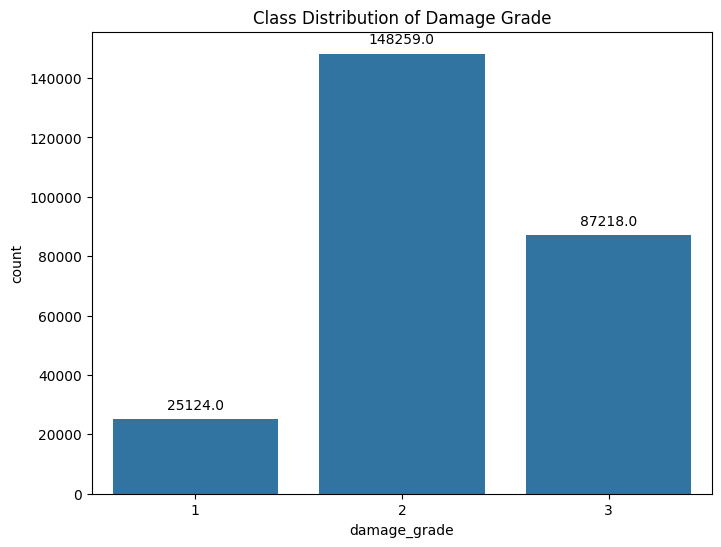

In [24]:
#Checking class balance in the target variable
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x=target)
plt.title("Class Distribution of Damage Grade")
#Displaying counts on top of bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
plt.show()

Nota Bene: There's signifant class imbalance. This will be addressed by creating class weights to be used for modeling

In [25]:
#Calculating class weights to address imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_df[target]), y=train_df[target])
class_weight_dict = {cls: weight for cls, weight in zip(np.unique(train_df[target]), class_weights)}
print("Class Weights:", class_weight_dict)

Class Weights: {np.int64(1): np.float64(3.4575306479859895), np.int64(2): np.float64(0.5859138399692431), np.int64(3): np.float64(0.9959756013666904)}


# 3. FEATURE ENGINEERING

## i. Creating New Engineered Features

In [26]:
#Creating interaction features
from sklearn.preprocessing import PolynomialFeatures

def create_all_interactions(train, test, poly_features=None, degree=2, include_bias=False):
    """
    Create both domain-driven and polynomial interaction features
    for earthquake damage prediction.

    Parameters:
        train (pd.DataFrame): training dataframe
        test (pd.DataFrame): test dataframe
        poly_features (list): numeric columns for polynomial interactions
        degree (int): polynomial degree (default=2, usually enough)
        include_bias (bool): include bias term (default=False)

    Returns:
        train (pd.DataFrame), test (pd.DataFrame): with new features added
    """

    # --- 1. Domain-driven interactions ---
    # Floors × Height Percentage
    train["floors_height_interaction"] = train["count_floors_pre_eq"] * train["height_percentage"]
    test["floors_height_interaction"]  = test["count_floors_pre_eq"]  * test["height_percentage"]

    # Floors ÷ Age
    train["floors_per_age"] = train["count_floors_pre_eq"] / (train["age"] + 1)
    test["floors_per_age"]  = test["count_floors_pre_eq"]  / (test["age"] + 1)

    # Height × Age
    train["height_age_interaction"] = train["height_percentage"] * train["age"]
    test["height_age_interaction"]  = test["height_percentage"]  * test["age"]

    # Roof × Floors (requires encoded roof_type_te)
    if "roof_type_te" in train.columns:
        train["roof_floors_interaction"] = train["roof_type_te"] * train["count_floors_pre_eq"]
        test["roof_floors_interaction"]  = test["roof_type_te"]  * test["count_floors_pre_eq"]

    # Foundation × Floors (requires encoded foundation_type_te)
    if "foundation_type_te" in train.columns:
        train["foundation_floors_interaction"] = train["foundation_type_te"] * train["count_floors_pre_eq"]
        test["foundation_floors_interaction"]  = test["foundation_type_te"]  * test["count_floors_pre_eq"]

    # Roof × Foundation
    if "roof_type_te" in train.columns and "foundation_type_te" in train.columns:
        train["roof_foundation_interaction"] = train["roof_type_te"] * train["foundation_type_te"]
        test["roof_foundation_interaction"]  = test["roof_type_te"]  * test["foundation_type_te"]

    # --- 2. Polynomial interactions (optional) ---
    if poly_features:
        poly = PolynomialFeatures(degree=degree, interaction_only=True, include_bias=include_bias)
        
        train_poly = poly.fit_transform(train[poly_features])
        test_poly  = poly.transform(test[poly_features])
        
        poly_feature_names = poly.get_feature_names_out(poly_features)

        train_poly_df = pd.DataFrame(train_poly, columns=poly_feature_names, index=train.index)
        test_poly_df  = pd.DataFrame(test_poly,  columns=poly_feature_names, index=test.index)

        # Drop the originals to avoid duplication
        train_poly_df = train_poly_df.drop(columns=poly_features)
        test_poly_df  = test_poly_df.drop(columns=poly_features)

        # Merge back into datasets
        train = pd.concat([train, train_poly_df], axis=1)
        test  = pd.concat([test, test_poly_df], axis=1)

    return train, test


In [27]:
# Choose numeric columns for polynomial expansion
numeric_feats = ["count_floors_pre_eq", "height_percentage", "age"]

# Create ALL interactions in one shot
train, test = create_all_interactions(train_df, test_df, poly_features=numeric_feats, degree=2)

print(train.filter(like="_interaction").head())  # see engineered features


   floors_height_interaction  height_age_interaction  roof_floors_interaction  \
0                         10                     150                 4.540048   
1                         14                      70                 4.540048   
2                         10                      50                 4.538608   
3                         10                      50                 4.538988   
4                         27                     270                 6.809145   

   foundation_floors_interaction  roof_foundation_interaction  
0                       4.659650                     5.288759  
1                       4.659650                     5.288759  
2                       4.659138                     5.286500  
3                       4.658851                     5.286617  
4                       6.989260                     5.287877  


In [28]:
test.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,legal_ownership_status_te,floors_height_interaction,floors_per_age,height_age_interaction,roof_floors_interaction,foundation_floors_interaction,roof_foundation_interaction,count_floors_pre_eq height_percentage,count_floors_pre_eq age,height_percentage age
0,300051,17,596,11307,3,20,7,6,t,r,...,2.244063,18,0.142857,120,6.808912,6.988718,5.287285,18.0,60.0,120.0
1,99355,6,141,11987,2,25,13,5,t,r,...,2.244063,10,0.076923,125,4.539274,4.659145,5.287285,10.0,50.0,125.0
2,890251,22,19,10044,2,5,4,5,t,r,...,2.244063,10,0.333333,25,4.539274,4.659145,5.287285,10.0,10.0,25.0
3,745817,26,39,633,1,0,19,3,t,r,...,2.244063,3,1.000000,0,1.572267,2.329573,3.662711,3.0,0.0,0.0
4,421793,17,289,7970,3,15,8,7,t,r,...,2.244063,21,0.187500,105,6.960520,6.988718,5.405013,21.0,45.0,105.0


In [29]:
train.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,legal_ownership_status_te,floors_height_interaction,floors_per_age,height_age_interaction,roof_floors_interaction,foundation_floors_interaction,roof_foundation_interaction,count_floors_pre_eq height_percentage,count_floors_pre_eq age,height_percentage age
0,802906,6,487,12198,2,30,6,5,t,r,...,2.244053,10,0.064516,150,4.540048,4.659650,5.288759,10.0,60.0,150.0
1,28830,8,900,2812,2,10,8,7,o,r,...,2.244053,14,0.181818,70,4.540048,4.659650,5.288759,14.0,20.0,70.0
2,94947,21,363,8973,2,10,5,5,t,r,...,2.243879,10,0.181818,50,4.538608,4.659138,5.286500,10.0,20.0,50.0
3,590882,22,418,10694,2,10,6,5,t,r,...,2.244209,10,0.181818,50,4.538988,4.658851,5.286617,10.0,20.0,50.0
4,201944,11,131,1488,3,30,8,9,t,r,...,2.244698,27,0.096774,270,6.809145,6.989260,5.287877,27.0,90.0,270.0


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 57 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   building_id                             260601 non-null  int64  
 1   geo_level_1_id                          260601 non-null  int64  
 2   geo_level_2_id                          260601 non-null  int64  
 3   geo_level_3_id                          260601 non-null  int64  
 4   count_floors_pre_eq                     260601 non-null  int64  
 5   age                                     260601 non-null  int64  
 6   area_percentage                         260601 non-null  int64  
 7   height_percentage                       260601 non-null  int64  
 8   land_surface_condition                  260601 non-null  object 
 9   foundation_type                         260601 non-null  object 
 10  roof_type                               2606

## ii. DImensionality Reduction with Feature Selection

In [35]:
train = train.drop(columns=categorical_train_features + ['building_id'])
test = test.drop(columns=categorical_train_features + ['building_id'])

In [33]:
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier

def model_based_feature_selection(train, test, target_col="damage_grade", n_features=200):
    # Shift labels to start at 0
    y = train[target_col] - 1
    X = train.drop(columns=[target_col])

    model = XGBClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X, y)

    selector = SelectFromModel(model, max_features=n_features, prefit=True)
    
    X_train_reduced = selector.transform(X)
    X_test_reduced  = selector.transform(test)

    # Rebuild DataFrames
    selected_features = X.columns[selector.get_support()]
    train_reduced = pd.DataFrame(X_train_reduced, columns=selected_features, index=train.index)
    test_reduced  = pd.DataFrame(X_test_reduced,  columns=selected_features, index=test.index)

    return train_reduced, test_reduced, selected_features



In [37]:
train_red, test_red, selected_features = model_based_feature_selection(train, test, target_col=target, n_features=200)
print("Selected Features:\n", selected_features)

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected Features:
 Index(['geo_level_1_id', 'geo_level_2_id', 'count_floors_pre_eq',
       'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone',
       'has_superstructure_stone_flag', 'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'foundation_type_te',
       'ground_floor_type_te', 'other_floor_type_te',
       'roof_foundation_interaction'],
      dtype='object')


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [38]:
train_red.head()

,geo_level_1_id,geo_level_2_id,count_floors_pre_eq,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,foundation_type_te,ground_floor_type_te,other_floor_type_te,roof_foundation_interaction
0,6.0,487.0,2.0,1.0,1.0,0.0,0.0,0.0,2.329825,2.309000,2.315525,5.288759
1,8.0,900.0,2.0,0.0,1.0,0.0,0.0,0.0,2.329825,2.252875,2.315525,5.288759
2,21.0,363.0,2.0,0.0,1.0,0.0,0.0,0.0,2.329569,2.309269,2.296421,5.286500
3,22.0,418.0,2.0,0.0,1.0,0.0,0.0,0.0,2.329426,2.309034,2.294378,5.286617
4,11.0,131.0,3.0,1.0,0.0,0.0,0.0,0.0,2.329753,2.309267,2.297974,5.287877


In [39]:
test_red.head()

,geo_level_1_id,geo_level_2_id,count_floors_pre_eq,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,foundation_type_te,ground_floor_type_te,other_floor_type_te,roof_foundation_interaction
0,17.0,596.0,3.0,0.0,1.0,0.0,0.0,0.0,2.329573,2.309104,2.315751,5.287285
1,6.0,141.0,2.0,0.0,1.0,0.0,0.0,0.0,2.329573,2.309104,2.315751,5.287285
2,22.0,19.0,2.0,0.0,1.0,0.0,0.0,0.0,2.329573,2.309104,2.315751,5.287285
3,26.0,39.0,1.0,0.0,0.0,0.0,0.0,1.0,2.329573,1.634205,2.042893,3.662711
4,17.0,289.0,3.0,0.0,1.0,0.0,0.0,0.0,2.329573,2.309104,2.315751,5.405013


# 4. MODEL DEVELOPMENT

In [40]:
#Importing necessary libraries for model development
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
#Creating a weighted model pipeline class
class WeightedModelPipeline:
    def __init__(self, models, n_splits=5, random_state=42):
        self.models = models
        self.n_splits = n_splits
        self.random_state = random_state
        self.results = {}
        self.best_model = None

    def compute_class_weights(self, y):
        classes = np.unique(y)
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
        return dict(zip(classes, weights))

    def cross_validate(self, X, y):
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)
        class_weights = self.compute_class_weights(y)

        for name, model in self.models.items():
            fold_scores = []
            oof_preds = np.zeros_like(y)

            for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
                X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
                y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

                # Map row-wise weights
                train_weights = y_train.map(class_weights)

                # Special case: LogisticRegression accepts class_weight directly
                if name == "Logistic Regression":
                    model.set_params(class_weight=class_weights)
                    model.fit(X_train, y_train)
                else:
                    model.fit(X_train, y_train, sample_weight=train_weights)

                preds = model.predict(X_valid)
                score = f1_score(y_valid, preds, average="macro")
                fold_scores.append(score)
                oof_preds[valid_idx] = preds

                print(f"{name} | Fold {fold}: F1_macro = {score:.4f}")

            mean_score = np.mean(fold_scores)
            std_score = np.std(fold_scores)
            self.results[name] = (mean_score, std_score)
            print(f"{name} | Mean F1_macro: {mean_score:.4f} ± {std_score:.4f}")
            print("-" * 40)

    def fit_final(self, X, y, model_name):
        """Fit the best model on full training data"""
        if model_name not in self.models:
            raise ValueError(f"Model {model_name} not found in pipeline")

        class_weights = self.compute_class_weights(y)
        model = self.models[model_name]

        if model_name == "Logistic Regression":
            model.set_params(class_weight=class_weights)
            model.fit(X, y)
        else:
            sample_weights = y.map(class_weights)
            model.fit(X, y, sample_weight=sample_weights)

        self.best_model = model
        return model

    def predict(self, X):
        if self.best_model is None:
            raise ValueError("No trained model found. Run fit_final first.")
        return self.best_model.predict(X)


In [41]:
# Shift labels to 0-based
y = train[target] - 1
X = train_red
X_test = test_red

# Define candidate models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, multi_class="multinomial"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=500, learning_rate=0.05,
                             max_depth=6, subsample=0.9,
                             colsample_bytree=0.9, n_jobs=-1, random_state=42)
}


In [42]:
# Initialize pipeline
pipeline = WeightedModelPipeline(models)

In [43]:
# Cross-validation
pipeline.cross_validate(X, y)


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class'

Logistic Regression | Fold 1: F1_macro = 0.4906


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression | Fold 2: F1_macro = 0.4876


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression | Fold 3: F1_macro = 0.4874


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression | Fold 4: F1_macro = 0.4882


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression | Fold 5: F1_macro = 0.4925
Logistic Regression | Mean F1_macro: 0.4892 ± 0.0020
----------------------------------------
Random Forest | Fold 1: F1_macro = 0.6235
Random Forest | Fold 2: F1_macro = 0.6226
Random Forest | Fold 3: F1_macro = 0.6229
Random Forest | Fold 4: F1_macro = 0.6223
Random Forest | Fold 5: F1_macro = 0.6179
Random Forest | Mean F1_macro: 0.6218 ± 0.0020
----------------------------------------
XGBoost | Fold 1: F1_macro = 0.6245
XGBoost | Fold 2: F1_macro = 0.6220
XGBoost | Fold 3: F1_macro = 0.6262
XGBoost | Fold 4: F1_macro = 0.6228
XGBoost | Fold 5: F1_macro = 0.6267
XGBoost | Mean F1_macro: 0.6245 ± 0.0019
----------------------------------------


In [50]:
# Train final model (say XGBoost performed best)
final_model = pipeline.fit_final(X, y, "XGBoost")

In [51]:
# Predict on test (shift back to 1,2,3 for submission)
y_test_pred = pipeline.predict(X_test) + 1



In [53]:
y_test_pred

array([3, 2, 2, ..., 1, 3, 1], shape=(86868,))

In [ ]:
submission = pd.DataFrame({"building_id": test_df['building_id'], "damage_grade": y_test_pred})

submission.head()

,building_id,damage_grade
0,300051,3
1,99355,2
2,890251,2
3,745817,1
4,421793,3


In [56]:
#Saving submission file
submission.to_csv("earthquake damage prediction submission.csv", index=False)